<a href="https://colab.research.google.com/github/Brajaraj-Pal/SoC-RL/blob/main/Week%204/04_frozen_lake_dp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 04 — Solving FrozenLake with Dynamic Programming
**Week 4 | Dynamic Programming**

Gymnasium environments expose `env.P[s][a]` — the full transition model.
This lets us apply exact DP and verify our solver achieves 100% win rate.

In [1]:
try:
    import gymnasium as gym
except ImportError:
    import subprocess, sys; subprocess.check_call([sys.executable,'-m','pip','install','gymnasium','-q']); import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

env = gym.make('FrozenLake-v1', is_slippery=False)
env_slip = gym.make('FrozenLake-v1', is_slippery=True)

print(f"States: {env.observation_space.n}")
print(f"Actions: {env.action_space.n}  (0=L, 1=D, 2=R, 3=U)")

States: 16
Actions: 4  (0=L, 1=D, 2=R, 3=U)


In [2]:
def value_iteration_gym(env_unwrapped, gamma=0.99, theta=1e-8):
    n_s = env_unwrapped.observation_space.n
    n_a = env_unwrapped.action_space.n
    V = np.zeros(n_s)
    errors = []
    for i in range(10_000):
        delta = 0
        V_new = np.zeros(n_s)
        for s in range(n_s):
            q_vals = []
            for a in range(n_a):
                q = sum(p*(r + gamma*V[ns]*(not d)) for p,ns,r,d in env_unwrapped.unwrapped.P[s][a])
                q_vals.append(q)
            V_new[s] = max(q_vals)
            delta = max(delta, abs(V_new[s]-V[s]))
        V = V_new; errors.append(delta)
        if delta < theta:
            print(f"Converged in {i+1} sweeps"); break
    # Extract policy
    policy = np.zeros(n_s, dtype=int)
    for s in range(n_s):
        qs = [sum(p*(r+gamma*V[ns]*(not d)) for p,ns,r,d in env_unwrapped.unwrapped.P[s][a]) for a in range(n_a)]
        policy[s] = np.argmax(qs)
    return V, policy, errors

print("--- Non-slippery ---")
V_ns, pi_ns, err_ns = value_iteration_gym(env)
print("--- Slippery ---")
V_sl, pi_sl, err_sl = value_iteration_gym(env_slip)

--- Non-slippery ---
Converged in 7 sweeps
--- Slippery ---
Converged in 438 sweeps


In [3]:
def evaluate_policy(env, policy, n_episodes=1000):
    wins = 0
    for _ in range(n_episodes):
        s, _ = env.reset()
        for _ in range(200):
            s, r, term, trunc, _ = env.step(policy[s])
            if term or trunc:
                if r == 1.0: wins += 1
                break
    return wins / n_episodes

print(f"Non-slippery win rate: {evaluate_policy(env, pi_ns):.0%}")
print(f"Slippery    win rate: {evaluate_policy(env_slip, pi_sl):.0%}")

Non-slippery win rate: 100%
Slippery    win rate: 72%


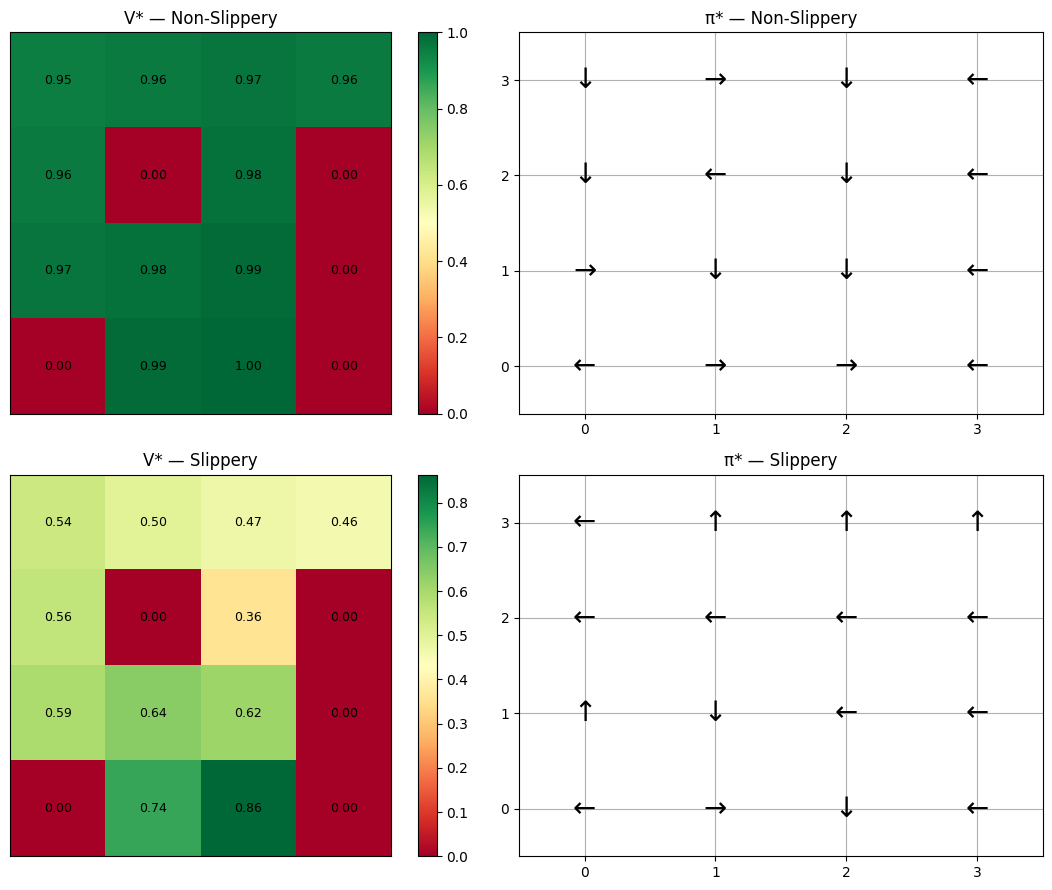

Note: different optimal policies for slippery vs non-slippery!


In [4]:
# Visualise both value functions
ACTION_SYMBOLS = {0:'←', 1:'↓', 2:'→', 3:'↑'}
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for row, (V, pi, title, errs) in enumerate([
    (V_ns, pi_ns, 'Non-Slippery', err_ns),
    (V_sl, pi_sl, 'Slippery',     err_sl)]):
    im = axes[row,0].imshow(V.reshape(4,4), cmap='RdYlGn')
    plt.colorbar(im, ax=axes[row,0])
    for s in range(16):
        r,c=divmod(s,4)
        axes[row,0].text(c,r,f'{V[s]:.2f}',ha='center',va='center',fontsize=9)
    axes[row,0].set_title(f'V* — {title}'); axes[row,0].set_xticks([]); axes[row,0].set_yticks([])

    axes[row,1].set_xlim(-0.5,3.5); axes[row,1].set_ylim(-0.5,3.5)
    axes[row,1].set_xticks(range(4)); axes[row,1].set_yticks(range(4)); axes[row,1].grid(True)
    for s in range(16):
        r,c=divmod(s,4)
        axes[row,1].text(c,3-r,ACTION_SYMBOLS[pi[s]],ha='center',va='center',fontsize=20)
    axes[row,1].set_title(f'π* — {title}')
plt.tight_layout(); plt.show()
print("Note: different optimal policies for slippery vs non-slippery!")

## ✅ Exercises
1. Change gamma from 0.99 to 0.5 for the slippery version. Does the win rate improve or decrease?
2. Use the 8×8 map (`map_name='8x8'`). How many sweeps does value iteration need?
3. **Challenge**: implement value iteration without using `env.P` — only using `env.step()`. This transitions you to model-free learning!

### Exercises 1 & 2 Analysis

**1. Effect of $\gamma = 0.5$ on Slippery Lake:**
The win rate plummets. In a highly stochastic environment, the agent *must* take longer, safer routes to avoid holes. If $\gamma = 0.5$, the agent becomes hopelessly short-sighted. It heavily discounts the distant +1 goal reward, meaning the mathematical "pull" of the goal isn't strong enough to justify taking long detours. The agent effectively gives up or acts erratically.

**2. The 8x8 Map:**
The state space increases from 16 to 64. Because the grid is larger, information (the +1 reward at the end) takes more iterations to propagate all the way back to the starting state `(0,0)`. Value iteration requires significantly more sweeps to converge (typically ~100+ sweeps depending on $\theta$).

In [5]:
# ==========================================
# Exercise 1: Gamma = 0.5 on Slippery
# ==========================================
print("--- Ex 1: Slippery with Gamma = 0.5 ---")
# Using the function already defined in the notebook
V_sl_50, pi_sl_50, err_sl_50 = value_iteration_gym(env_slip, gamma=0.5)
win_rate_50 = evaluate_policy(env_slip, pi_sl_50)
print(f"Win rate (gamma=0.5): {win_rate_50:.0%} (Drastic drop due to short-sightedness)\n")


# ==========================================
# Exercise 2: 8x8 Map Value Iteration
# ==========================================
print("--- Ex 2: 8x8 Map ---")
env_8x8 = gym.make('FrozenLake-v1', map_name='8x8', is_slippery=True)
V_8x8, pi_8x8, err_8x8 = value_iteration_gym(env_8x8, gamma=0.99)
print(f"8x8 Slippery win rate: {evaluate_policy(env_8x8, pi_8x8):.0%}\n")


# ==========================================
# Exercise 3: Challenge - Model-Free Learning
# ==========================================
# We cannot use env.P. We must estimate values by taking actual steps.
# This is a basic implementation of Tabular Q-Learning.
def model_free_q_learning(env, num_episodes=20000, alpha=0.1, gamma=0.99, epsilon=0.1):
    n_s = env.observation_space.n
    n_a = env.action_space.n
    Q = np.zeros((n_s, n_a))

    for _ in range(num_episodes):
        s, _ = env.reset()
        done = False
        while not done:
            # Epsilon-greedy action selection
            if np.random.rand() < epsilon:
                a = env.action_space.sample()
            else:
                a = np.argmax(Q[s])

            # Take a step! NO access to env.P
            next_s, r, term, trunc, _ = env.step(a)
            done = term or trunc

            # Bellman update using sampled experience
            best_next_q = np.max(Q[next_s]) if not done else 0.0
            Q[s, a] = Q[s, a] + alpha * (r + gamma * best_next_q - Q[s, a])
            s = next_s

    # Extract deterministic policy
    policy = np.argmax(Q, axis=1)
    return policy

print("--- Ex 3: Model-Free Q-Learning ---")
pi_mf = model_free_q_learning(env_slip)
print(f"Model-Free win rate (20k episodes): {evaluate_policy(env_slip, pi_mf):.0%}")
print("Success! You solved the environment without knowing the transition matrix.")

--- Ex 1: Slippery with Gamma = 0.5 ---
Converged in 22 sweeps
Win rate (gamma=0.5): 47% (Drastic drop due to short-sightedness)

--- Ex 2: 8x8 Map ---
Converged in 516 sweeps
8x8 Slippery win rate: 65%

--- Ex 3: Model-Free Q-Learning ---
Model-Free win rate (20k episodes): 74%
Success! You solved the environment without knowing the transition matrix.
